In [1]:
import openai
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import re
import time
from openai import OpenAI
import json
import pickle
import pandas as pd
import os

sys.path += ['../src/']

#from model import *
import model as mod
import model

In [2]:
path_exp = '../results/experiments/'

In [3]:
openai.__version__

'1.3.6'

In [4]:
# set simulation parameters
seed = 0
np.random.seed(seed)
noise_mean = 0
noise_sd = 1/4
temperature = 0.7
n_steps=4
n_agents=3

In [5]:
expmnt_num = 1
instruction_type = 'prompteng'
feedback='neg'

In [6]:
def check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, n_steps, n_agents):
    temp_str = temp_str = str(temperature).replace('.', '-')
    file_name = f"expmnt_results_{feedback}_{instruction_type}_num_{expmnt_num}_temp_{temp_str}_ntime_{n_steps}_nagents_{n_agents}.csv"
    file_path = os.path.join(path_exp, file_name)

    # Check if the file exists
    if os.path.exists(file_path):
        print(f"File {file_name} already exists.")
        # Increase exp_number 
        # TODO do this recursively to guarantee there is not overlap
        expmnt_num += 1
        print(f"Changing experiment number to {expmnt_num}, double check this is okay")
        return expmnt_num
    else:
        print(f"File {file_name} does not exist. Safe to proceed.")
        return expmnt_num

In [7]:
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, n_steps, n_agents)

File expmnt_results_neg_prompteng_num_1_temp_0-7_ntime_4_nagents_3.csv does not exist. Safe to proceed.


In [10]:
p_array, pe_agents_time, rewards_agents_time, messages_list  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, n_steps=n_steps, n_agents=n_agents,
                feedback='neg', instruction_type='prompteng', prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
ChatGPT: {"reasoning": "Since this is the first time step and I don't have any prior data, I will make an initial prediction based on my understanding of market dynamics. I will assume that the price will be around the midpoint of the price range, so my initial prediction is 50.", "predictedValue": 50}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
ChatGPT: {
  "reasoning": "Since we do not have any historical data, we will make an initial price prediction based on the average historical price in the market. This prediction assumes that the market dynamics have been relatively stable in the past. We will start with an initial prediction of 50 euros, which is the average of the possible price range.",
  "predictedValue": 50
}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step,

In [4]:
p_array

NameError: name 'p_array' is not defined

In [12]:
pe_agents_time

array([[50., 55., 50., 55.],
       [50., 70., 65., 68.],
       [50., 48., 46., 44.]])

In [13]:
rewards_agents_time

array([[0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.48, 0.39],
       [0.  , 0.  , 0.  , 0.  ]])

In [14]:
with open('../results/experiments/expmnt_messages_neg_prompteng_num_1_temp_0-7_ntime_4_nagents_3.pkl', 'rb') as f:
    x = pickle.load(f)

In [17]:
x[0]

[{'role': 'system',
  'content': 'As an advisor in a product market, your task is to predict market prices P(t) for 50 time periods. Each prediction, denoted as V(t) for period t, should be made one period in advance. Your earnings increase with the accuracy of your predictions. Predicted prices should range from 0 to 100 euros. Your objective is to maximize your earnings. Use historical data and market dynamics for precise predictions.'},
 {'role': 'system',
  'content': 'Market Dynamics: The price of the product will be determined by the law of supply and demand. The size of demand is dependent on the price. If the price goes up, demand will go down. The supply on the market is determined by the importers of the product. Higher price predictions make an importer import a higher quantity, increasing supply. There are several large importers active on this market and each of them is guided by an advisor. Total supply is largely determined by the sum of the individual supplies of these 

In [23]:
expmnt_num = 2
n_agents = 3
n_steps = 5
instruction_type = 'original_30-50w'
feedback='neg'
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, n_steps, n_agents)

File expmnt_results_neg_original_30-50w_num_2_temp_0-7_ntime_5_nagents_3.csv does not exist. Safe to proceed.


In [24]:
#on =original negative
p_array_on, pe_agents_time_on, rewards_agents_time_on, messages_list_on  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, n_steps=n_steps, n_agents=n_agents,
                feedback=feedback, instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
ChatGPT: {"reasoning": "Based on historical data and market trends, I predict that the market price in period 1 will be 45.50 euros.", "predictedValue": 45.50}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
ChatGPT: {
  "reasoning": "Based on historical data and market trends, I predict that the market price will be slightly higher than the previous period.",
  "predictedValue": 31.50
}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
ChatGPT: {
  "reasoning": "Based on historical data and market trends, I predict that the price will remain stable in the first period.",
  "predictedValue": 50.00
}
 
 Time: 1, agent: 0 

{'role': 'user', 'content': "This time step's data: ```market prices: 77.27;             your predictions: 45.5;        

In [25]:
p_array_on

array([77.27, 56.43, 64.55, 52.4 , 68.61])

In [26]:
pe_agents_time_on

array([[45.5 , 72.8 , 60.25, 66.8 , 50.6 ],
       [31.5 , 33.75, 51.2 , 68.9 , 48.75],
       [50.  , 85.  , 55.  , 70.  , 55.  ]])

In [27]:
rewards_agents_time_on

array([[0.  , 0.  , 0.31, 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ]])

In [8]:
expmnt_num = 1
n_agents = 3
n_steps = 5
instruction_type = 'original_30-50w'
feedback='pos'
expmnt_num = check_existing_file(path_exp, expmnt_num, feedback, instruction_type, temperature, n_steps, n_agents)

In [17]:
#op =original positive
p_array_op, pe_agents_time_op, rewards_agents_time_op, messages_list_op  = mod.run_experiment(seed,\
                expmnt_num, noise_mean, noise_sd, temperature, n_steps=n_steps, n_agents=n_agents,
                feedback='pos', instruction_type=instruction_type, prints_on=True,\
                save_res_bool=True, path_exp=path_exp)

 
 Time: 0, agent: 0 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
ChatGPT: {
  "reasoning": "As this is the first time step, I do not have any historical data to base my prediction on. Therefore, I will make an initial prediction based on a neutral assumption. Since the price can range from 0 to 100 euros, I will predict the midpoint of this range, which is 50 euros.",
  "predictedValue": 50
}
 
 Time: 0, agent: 1 

{'role': 'user', 'content': 'This is the first time step, give an initial price prediction'}
ChatGPT: {
  "reasoning": "Since this is the first time step and there is no prior data available, I will make an initial price prediction based on general market trends and assumptions. I will start with a conservative estimate of 50 euros as the market price. This is a neutral starting point that can be adjusted based on future data and market dynamics.",
  "predictedValue": 50
}
 
 Time: 0, agent: 2 

{'role': 'user', 'content': '

ChatGPT: {
  "reasoning": "Analyzing the available data, I can observe that the market price in the previous four periods has been consistently higher than my predictions. This suggests a sustained strong demand in the market. Additionally, my previous prediction was slightly lower than the actual market price, resulting in a positive earnings. Considering these factors, I will increase my prediction for the next time step to account for the continued strong demand. Therefore, for the next time step, I predict the market price to be 54 euros.",
  "predictedValue": 54
}
 
 Time: 4, agent: 2 

{'role': 'user', 'content': "This time step's data: ```market prices: 50.92, 51.82, 52.71, 53.69;             your predictions: 50.0, 51.5, 52.2, 53.0;             Total earnings: 1.99``` Make your next prediction"}
ChatGPT: {
  "reasoning": "Based on the provided data, I will update my prediction for the market price at time step 5. The market price continued to increase from the previous time ste

In [18]:
p_array_op

array([50.92, 51.82, 52.71, 53.69, 54.32])

In [19]:
pe_agents_time_op

array([[50.  , 51.42, 52.08, 52.35, 52.63],
       [50.  , 51.  , 52.  , 53.  , 54.  ],
       [50.  , 51.5 , 52.2 , 53.  , 54.  ]])

In [20]:
rewards_agents_time_op

array([[0.49, 0.5 , 0.5 , 0.48, 0.47],
       [0.49, 0.49, 0.49, 0.5 , 0.5 ],
       [0.49, 0.5 , 0.5 , 0.5 , 0.5 ]])

In [5]:
p_list = np.array([50.92, 51.82, 52.71, 53.69, 54.32])
pe_list = np.array([[50.  , 51.42, 52.08, 52.35, 52.63],
       [50.  , 51.  , 52.  , 53.  , 54.  ],
       [50.  , 51.5 , 52.2 , 53.  , 54.  ]])
earnings_list = np.array([[0.49, 0.5 , 0.5 , 0.48, 0.47],
       [0.49, 0.49, 0.49, 0.5 , 0.5 ],
       [0.49, 0.5 , 0.5 , 0.5 , 0.5 ]])

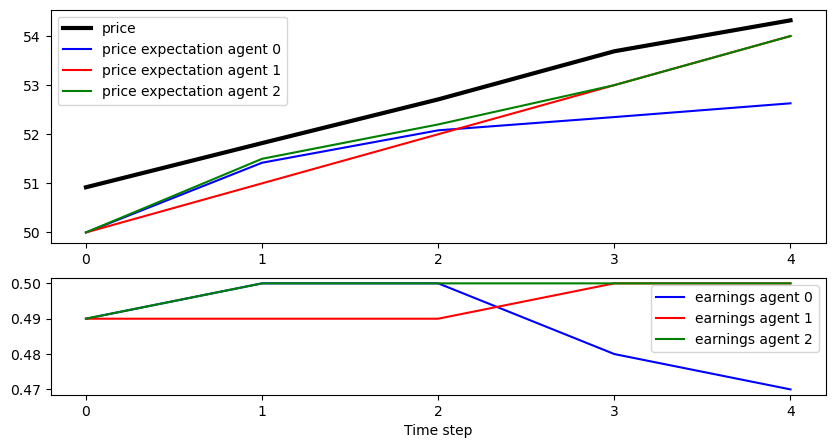

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1]})
n_agents = 3
n_steps = 5
colors = ["blue","red","green","orange","violet","cyan","gold"]

axes[0].plot(p_list,label="price",color="black",linewidth = 3)
for i in range(n_agents):
    axes[0].plot(pe_list[i,:],label="price expectation agent "+str(i),color=colors[i])
    axes[1].plot(earnings_list[i,:],label="earnings agent "+str(i),color=colors[i])

#axes[0].set_ylim(0,100)
axes[0].legend()
axes[1].legend()

axes[1].set_xlabel("Time step")
axes[0].set_xticks(range(n_steps))
axes[1].set_xticks(range(n_steps))